In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('val_feature.csv', sep=';')

In [3]:
df.head()

,CC_ID,SCORING_ID,PARAM_ID,VALUE_ID,LOAN_ID,SCORE_BALL,APPLICATION_DATE,TARGET_30,TARGET_60,TARGET_90
0,597722,184,186,3061,1504047,1,02.12.2024,0.0,0.0,0.0
1,597722,184,187,3048,1504047,3,02.12.2024,0.0,0.0,0.0
2,597722,184,190,3046,1504047,6,02.12.2024,0.0,0.0,0.0
3,597722,184,191,8177,1504047,6,02.12.2024,0.0,0.0,0.0
4,597722,184,192,8178,1504047,5,02.12.2024,0.0,0.0,0.0


In [4]:
df.shape

(1293947, 10)

In [5]:
df.head()

,CC_ID,SCORING_ID,PARAM_ID,VALUE_ID,LOAN_ID,SCORE_BALL,APPLICATION_DATE,TARGET_30,TARGET_60,TARGET_90
0,597722,184,186,3061,1504047,1,02.12.2024,0.0,0.0,0.0
1,597722,184,187,3048,1504047,3,02.12.2024,0.0,0.0,0.0
2,597722,184,190,3046,1504047,6,02.12.2024,0.0,0.0,0.0
3,597722,184,191,8177,1504047,6,02.12.2024,0.0,0.0,0.0
4,597722,184,192,8178,1504047,5,02.12.2024,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1293947 entries, 0 to 1293946
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   CC_ID             1293947 non-null  int64  
 1   SCORING_ID        1293947 non-null  int64  
 2   PARAM_ID          1293947 non-null  int64  
 3   VALUE_ID          1293947 non-null  int64  
 4   LOAN_ID           1293947 non-null  int64  
 5   SCORE_BALL        1293947 non-null  int64  
 6   APPLICATION_DATE  1293947 non-null  object 
 7   TARGET_30         1242881 non-null  float64
 8   TARGET_60         1242881 non-null  float64
 9   TARGET_90         1242881 non-null  float64
dtypes: float64(3), int64(6), object(1)
memory usage: 98.7+ MB


In [7]:
df['APPLICATION_DATE'] = pd.to_datetime(
    df['APPLICATION_DATE'],
    format='%d.%m.%Y'
)
df[df['TARGET_90'].isnull()]
df = df.dropna(subset=['TARGET_90'])

In [8]:
data = df.copy()
df = df[df['SCORING_ID'] == 727]

In [9]:
df = df[~df['CC_ID'].isin([1021846, 1040067])]

In [10]:
df.shape

(319253, 10)

In [11]:
bin_stats = (
    df.groupby(['PARAM_ID', 'VALUE_ID'])
      .agg(
          cnt=('TARGET_90', 'size'),
          bad=('TARGET_90', 'sum')
      )
      .reset_index()
)

bin_stats['good'] = (
    bin_stats['cnt']
    - bin_stats['bad']
)

In [12]:
bin_stats['good_pct'] = (
    bin_stats['good'] + 0.5
) / (
    bin_stats.groupby('PARAM_ID')['good']
             .transform('sum')
)

bin_stats['bad_pct'] = (
    bin_stats['bad'] + 0.5
) / (
    bin_stats.groupby('PARAM_ID')['bad']
             .transform('sum')
)

bin_stats['WOE'] = np.log(
    bin_stats['good_pct']
    /
    bin_stats['bad_pct']
)

In [13]:
bin_stats['IV'] = (
    bin_stats['good_pct']
    - bin_stats['bad_pct']
) * bin_stats['WOE']

iv_table = (
    bin_stats
    .groupby('PARAM_ID')['IV']
    .sum()
    .reset_index()
    .sort_values('IV', ascending=False)
)

print(iv_table)

    PARAM_ID        IV
0         11  0.843208
1         34  0.803353
12       210  0.582017
3        187  0.380426
6        190  0.302204
18       253  0.142042
10       200  0.109914
13       227  0.097206
7        191  0.034790
2        186  0.031502
15       232  0.021484
5        189  0.019976
16       233  0.007671
17       250  0.003772
9        194  0.000006
11       204  0.000005
14       231  0.000005
8        193  0.000005
4        188  0.000005


In [14]:
bin_stats[['WOE']].describe()

,WOE
count,66.000000
mean,-0.052728
std,0.802787
min,-2.154431
25%,-0.572757
50%,0.008220
75%,0.303610
max,1.923827


In [15]:
bin_stats.sort_values('WOE', ascending=False).head(10)

,PARAM_ID,VALUE_ID,cnt,bad,good,good_pct,bad_pct,WOE,IV
19,187,10416,1389,2.0,1387.0,0.073784,0.010776,1.923827,0.121216
28,189,10442,152,0.0,152.0,0.008110,0.002155,1.325171,0.007891
3,11,10400,1563,5.0,1558.0,0.082877,0.023707,1.251590,0.074057
30,189,10444,135,0.0,135.0,0.007206,0.002155,1.206978,0.006096
29,189,10443,128,0.0,128.0,0.006833,0.002155,1.153935,0.005398
51,210,10407,1942,8.0,1934.0,0.102872,0.036638,1.032397,0.068379
2,11,10399,6562,30.0,6532.0,0.347381,0.131466,0.971678,0.209800
53,227,11608,1056,7.0,1049.0,0.093181,0.037688,0.905193,0.050232
9,34,10458,10529,54.0,10475.0,0.557059,0.234914,0.863453,0.278158
63,253,43828,793,1.0,792.0,0.105078,0.045455,0.837992,0.049964


In [16]:
df_woe = df.merge(
    bin_stats[
        [
            'PARAM_ID',
            'VALUE_ID',
            'WOE'
        ]
    ],
    on=['PARAM_ID', 'VALUE_ID'],
    how='left'
)

In [17]:
X = (
    df_woe
    .pivot_table(
        index='CC_ID',
        columns='PARAM_ID',
        values='WOE',
        aggfunc='first'
    )
)

target_df = (
    df_woe[
        ['CC_ID', 'TARGET_90']
    ]
    .drop_duplicates()
    .set_index('CC_ID')
)

X = X.join(target_df)

In [18]:
from sklearn.linear_model import LogisticRegression

X_train = (
    X.drop(columns=['TARGET_90'])
     .fillna(0)
)

y_train = X['TARGET_90']



X_filtered = X_train.drop(columns=[189, 204])

lr = LogisticRegression(
    max_iter=2000,
    C=1,
    solver='lbfgs'
)

lr.fit(
    X_filtered,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [19]:
coef_df = pd.DataFrame({
    'PARAM_ID': X_filtered.columns,
    'BETA': lr.coef_[0]
})

coef_df = coef_df.sort_values(
    'BETA',
    ascending=False
)

print(coef_df)

   PARAM_ID      BETA
15      250  0.511046
12      231  0.007068
7       193  0.005067
4       188  0.005067
8       194 -0.028137
5       190 -0.305316
16      253 -0.501667
10      210 -0.527003
1        34 -0.554598
0        11 -0.585077
14      233 -0.632489
13      232 -0.795707
3       187 -0.877107
9       200 -0.882007
2       186 -0.935064
11      227 -1.246946
6       191 -2.188686


In [20]:
coef_df.sort_values('BETA')

,PARAM_ID,BETA
6,191,-2.188686
11,227,-1.246946
2,186,-0.935064
9,200,-0.882007
3,187,-0.877107
13,232,-0.795707
14,233,-0.632489
0,11,-0.585077
1,34,-0.554598
10,210,-0.527003


In [21]:
corr = X_filtered.corr().abs()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
)

high_corr.stack().sort_values(ascending=False).head(20)

188  193    1.000000
194  250    0.618643
11   34     0.475427
34   190    0.333665
     210    0.320585
188  250    0.309994
193  250    0.309994
11   210    0.219603
     190    0.196504
34   191    0.193919
193  194    0.191775
188  194    0.191775
200  227    0.162408
190  210    0.137606
186  210    0.117378
190  191    0.113575
200  250    0.112703
11   186    0.108377
187  210    0.104225
200  253    0.085360
dtype: float64

In [22]:
tmp = (
    df.groupby(
        ['PARAM_ID','VALUE_ID']
    )
    .agg(
        bad_rate=('TARGET_90','mean')
    )
    .reset_index()
)
tmp.head()

,PARAM_ID,VALUE_ID,bad_rate
0,11,10397,0.061518
1,11,10398,0.010976
2,11,10399,0.004572
3,11,10400,0.003199
4,34,10453,0.080000


In [36]:
new_points = (
    bin_stats
    .merge(
        coef_df,
        on='PARAM_ID',
        how='inner'
    )
)

# ============================
# Scorecard parametrlari
# ============================
PDO = 20
factor = PDO / np.log(2)

# ============================
# Xom (raw) point
# ============================
new_points['RAW_POINT'] = (
    -new_points['BETA']
    * new_points['WOE']
    * factor
)

# ============================
# Har bir parametr bo'yicha
# minimum pointni 0 ga surish
# ============================
new_points['NEW_POINT'] = (
    new_points['RAW_POINT']
    -
    new_points.groupby('PARAM_ID')['RAW_POINT']
              .transform('min')
)

# ============================
# Integer point
# ============================
new_points['NEW_POINT'] = (
    new_points['NEW_POINT']
    .round()
    .astype(int)
)

# ============================
# Tekshirish
# ============================
point_summary = (
    new_points
    .groupby('PARAM_ID')
    .agg(
        min_point=('NEW_POINT', 'min'),
        max_point=('NEW_POINT', 'max'),
        n_bins=('VALUE_ID', 'count')
    )
    .reset_index()
)

print(point_summary)

    PARAM_ID  min_point  max_point  n_bins
0         11          0         49       4
1         34          0         48       6
2        186          0         15       2
3        187          0         79      14
4        188          0          0       1
5        190          0         17       4
6        191          0         31       5
7        193          0          0       1
8        194          0          0       1
9        200          0         22       4
10       210          0         36       6
11       227          0         40       3
12       231          0          0       1
13       232          0         25       3
14       233          0          4       2
15       250          0          0       1
16       253          0         17       3


In [37]:
selected_params = coef_df['PARAM_ID'].tolist()

df_cmp = df[
    df['PARAM_ID'].isin(selected_params)
].copy()

df_new = df_cmp.merge(
    new_points[
        [
            'PARAM_ID',
            'VALUE_ID',
            'NEW_POINT'
        ]
    ],
    on=[
        'PARAM_ID',
        'VALUE_ID'
    ],
    how='left'
)

score_compare = (
    df_new
    .groupby('CC_ID')
    .agg(
        OLD_SCORE=('SCORE_BALL', 'sum'),
        NEW_SCORE=('NEW_POINT', 'sum'),
        TARGET=('TARGET_90', 'max')
    )
    .reset_index()
)

In [38]:
from sklearn.metrics import roc_auc_score

auc_old = roc_auc_score(
    score_compare['TARGET'],
    -score_compare['OLD_SCORE']
)

auc_new = roc_auc_score(
    score_compare['TARGET'],
    -score_compare['NEW_SCORE']
)

gini_old = 2 * auc_old - 1
gini_new = 2 * auc_new - 1

print('OLD AUC :', auc_old)
print('NEW AUC :', auc_new)

print('OLD GINI:', gini_old)
print('NEW GINI:', gini_new)

OLD AUC : 0.729832262145981
NEW AUC : 0.8420850562487967
OLD GINI: 0.4596645242919619
NEW GINI: 0.6841701124975934


In [39]:
from scipy.stats import ks_2samp

good = score_compare.loc[
    score_compare['TARGET']==0,
    'NEW_SCORE'
]

bad = score_compare.loc[
    score_compare['TARGET']==1,
    'NEW_SCORE'
]

ks = ks_2samp(
    good,
    bad
).statistic

In [40]:
ks

0.5692208601894213

In [41]:
score_compare.head()

,CC_ID,OLD_SCORE,NEW_SCORE,TARGET
0,677119,740,296,0.0
1,677131,640,234,0.0
2,766406,700,241,0.0
3,767469,620,278,0.0
4,783013,750,247,0.0


In [42]:
score_compare.describe()

,CC_ID,OLD_SCORE,NEW_SCORE,TARGET
count,1.903700e+04,19037.000000,19037.000000,19037.000000
mean,1.329707e+06,527.309030,222.491569,0.012187
std,3.139133e+05,91.065135,37.698506,0.109722
min,6.771190e+05,337.000000,72.000000,0.000000
25%,1.080033e+06,457.000000,200.000000,0.000000
50%,1.292100e+06,530.000000,225.000000,0.000000
75%,1.541573e+06,597.000000,248.000000,0.000000
max,2.471702e+06,800.000000,353.000000,1.000000


In [43]:
score_compare['DECILE'] = pd.qcut(
    score_compare['NEW_SCORE'],
    10,
    labels=False,
    duplicates='drop'
)

rank_table = (
    score_compare
    .groupby('DECILE')
    .agg(
        cnt=('TARGET', 'size'),
        bad_rate=('TARGET', 'mean'),
        avg_score=('NEW_SCORE', 'mean')
    )
    .reset_index()
)

rank_table

,DECILE,cnt,bad_rate,avg_score
0,0,1969,0.073134,150.029964
1,1,1900,0.014737,184.103684
2,2,1886,0.010074,200.495228
3,3,1911,0.007326,211.658817
4,4,1898,0.001581,221.204426
5,5,1949,0.004105,229.977424
6,6,1908,0.001048,238.814990
7,7,1998,0.004004,248.906406
8,8,1766,0.002265,260.975651
9,9,1852,0.001080,283.921706


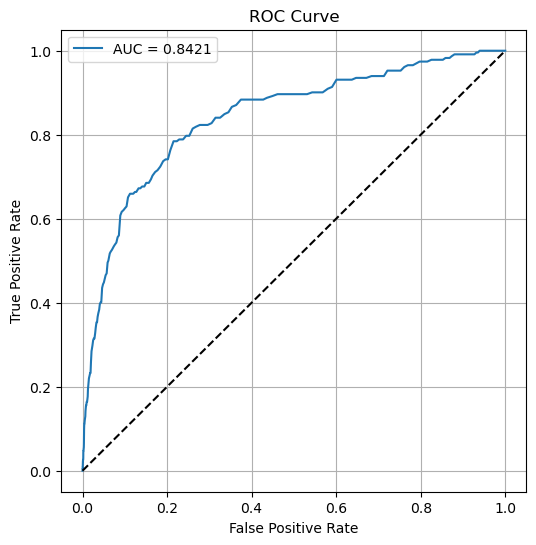

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_true = score_compare['TARGET']
y_score = -score_compare['NEW_SCORE']

fpr, tpr, _ = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

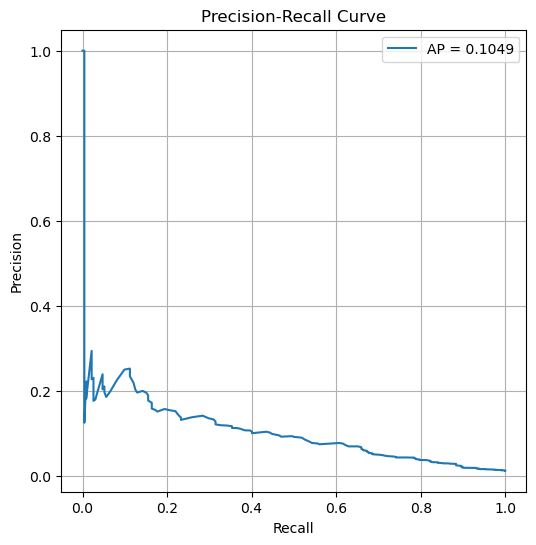

In [53]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(
    y_true,
    y_score
)

ap = average_precision_score(
    y_true,
    y_score
)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f'AP = {ap:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

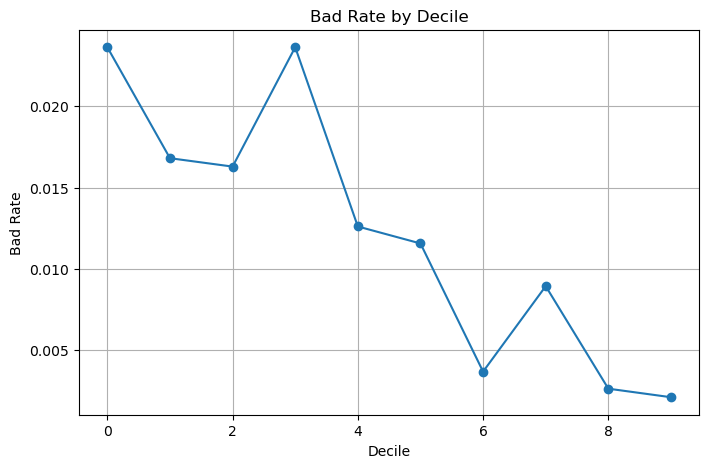

In [56]:
lift = lift_table.copy()

plt.figure(figsize=(8,5))
plt.plot(
    lift.index,
    lift['Bad_Rate'],
    marker='o'
)

plt.xlabel("Decile")
plt.ylabel("Bad Rate")
plt.title("Bad Rate by Decile")
plt.grid(True)
plt.show()

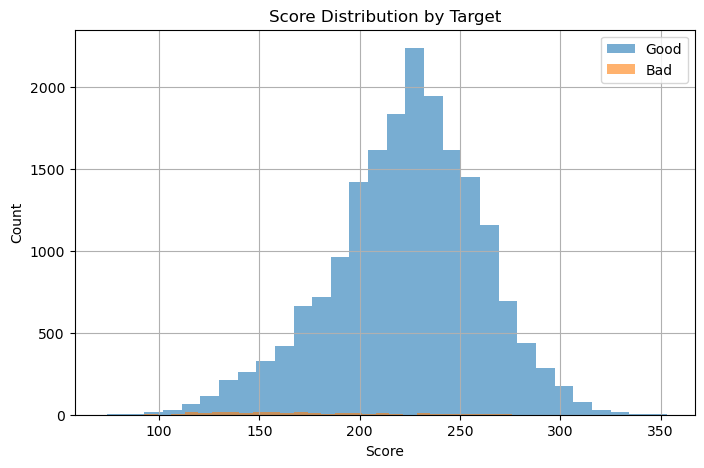

In [58]:
plt.figure(figsize=(8,5))

plt.hist(
    score_compare.loc[
        score_compare.TARGET==0,
        'NEW_SCORE'
    ],
    bins=30,
    alpha=0.6,
    label='Good'
)

plt.hist(
    score_compare.loc[
        score_compare.TARGET==1,
        'NEW_SCORE'
    ],
    bins=30,
    alpha=0.6,
    label='Bad'
)

plt.legend()
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Score Distribution by Target")
plt.grid(True)

plt.show()

In [59]:
score_compare['DECILE'] = pd.qcut(
    score_compare['NEW_SCORE'],
    10,
    duplicates='drop'
)

rank_table = (
    score_compare
    .groupby('DECILE')
    .agg(
        Clients=('TARGET','count'),
        Bads=('TARGET','sum'),
        Bad_Rate=('TARGET','mean'),
        Avg_Score=('NEW_SCORE','mean')
    )
)

print(rank_table)

                 Clients   Bads  Bad_Rate   Avg_Score
DECILE                                               
(71.999, 172.0]     1969  144.0  0.073134  150.029964
(172.0, 193.0]      1900   28.0  0.014737  184.103684
(193.0, 206.0]      1886   19.0  0.010074  200.495228
(206.0, 216.0]      1911   14.0  0.007326  211.658817
(216.0, 225.0]      1898    3.0  0.001581  221.204426
(225.0, 234.0]      1949    8.0  0.004105  229.977424
(234.0, 243.0]      1908    2.0  0.001048  238.814990
(243.0, 254.0]      1998    8.0  0.004004  248.906406
(254.0, 268.0]      1766    4.0  0.002265  260.975651
(268.0, 353.0]      1852    2.0  0.001080  283.921706


C:\Users\sh.nabiyev\AppData\Local\Temp\ipykernel_17552\2005121863.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('DECILE')
